<a href="https://colab.research.google.com/github/CalculatedContent/xgboost2ww/blob/main/notebooks/AdultIncome_LongRun_Alpha_Tracking.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


# Adult Income Long-Run Alpha Tracking (Single Configuration)


In [25]:
from pathlib import Path
import os
import platform

RANDOM_STATE = 42

CPU_THREADS = max(1, (os.cpu_count() or 1) - 1)
IS_APPLE_SILICON = platform.system() == 'Darwin' and platform.machine() == 'arm64'

params = {
    'max_depth': 4,
    'eta': 0.05,
    'subsample': 0.9,
    'colsample_bytree': 0.8,
    'min_child_weight': 5,
    'reg_lambda': 5.0,
    'reg_alpha': 0.5,
    'gamma': 1.0,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    # Apple Silicon (M1/M2/M3) benefits from CPU histogram + multithreading.
    # XGBoost GPU backends are not used on macOS ARM, so tune CPU threads instead.
    'tree_method': 'hist',
    'nthread': CPU_THREADS,
    'seed': RANDOM_STATE,
}

TOTAL_ROUNDS = 1200
CHUNK_SIZE = 25
N_STEPS = TOTAL_ROUNDS // CHUNK_SIZE
CHECKPOINT_EVERY_STEPS = 1

in_colab = False
try:
    from google.colab import drive
    in_colab = True
except ImportError:
    drive = None

if in_colab:
    drive.mount('/content/drive', force_remount=False)
    project_root = Path('/content/drive/MyDrive/xgboost2ww_runs/adult_income_longrun_alpha_tracking')
    print(f'Google Drive enabled: {project_root}')
else:
    project_root = Path('.')
    print('Google Drive unavailable; using local notebook storage.')

results_dir = project_root / 'results'
models_dir = project_root / 'models'
results_dir.mkdir(parents=True, exist_ok=True)
models_dir.mkdir(parents=True, exist_ok=True)

results_path_csv = results_dir / 'adult_income_longrun_alpha_tracking.csv'
results_path_feather = results_dir / 'adult_income_longrun_alpha_tracking.feather'
latest_model_path = models_dir / 'adult_income_longrun_latest.json'

print(f'TOTAL_ROUNDS={TOTAL_ROUNDS}, CHUNK_SIZE={CHUNK_SIZE}, N_STEPS={N_STEPS}')
print(f'CHECKPOINT_EVERY_STEPS={CHECKPOINT_EVERY_STEPS}')
print(f'CPU_THREADS={CPU_THREADS} | IS_APPLE_SILICON={IS_APPLE_SILICON}')
print(f'Results CSV path: {results_path_csv}')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive enabled: /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking
TOTAL_ROUNDS=3000, CHUNK_SIZE=50, N_STEPS=60
CHECKPOINT_EVERY_STEPS=2
Results CSV path: /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking/results/spambase_longrun_alpha_tracking.csv


## 1) Bootstrap environment

In [17]:
%pip install -q xgboost weightwatcher scikit-learn pandas matplotlib seaborn scipy feather-format
!git clone --depth 1 https://github.com/CalculatedContent/xgboost2ww.git /tmp/xgboost2ww-src || true
%pip install -q /tmp/xgboost2ww-src


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## 2) Imports

In [18]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import xgboost as xgb
import weightwatcher as ww
from xgboost2ww import convert

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

## 3) Load Adult Income dataset


In [19]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

adult = fetch_openml(data_id=1590, as_frame=True)
df = adult.frame.copy()

y = (df['class'].astype(str) == '>50K').astype(int)
X_raw = df.drop(columns=['class'])

categorical_cols = X_raw.select_dtypes(include=['object', 'category']).columns
numeric_cols = X_raw.select_dtypes(exclude=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numeric_cols),
    ]
)

X = preprocessor.fit_transform(X_raw).astype(np.float32)

print(f'X shape: {X.shape}')
print(f'y mean (income >50K prevalence): {y.mean():.3f}')


X shape: (4601, 57)
y mean (spam prevalence): 0.394


,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,word_freq_conference,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.0,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.0,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.0,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.0,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191


## 4) Train/test split (80/20) and scaling


In [20]:
from scipy import sparse

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

if sparse.issparse(X_train):
    scaler = StandardScaler(with_mean=False)
else:
    scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)
y_train_np = np.asarray(y_train).astype(np.int32).reshape(-1)
y_test_np = np.asarray(y_test).astype(np.int32).reshape(-1)

# xgboost2ww currently expects dense numpy arrays in convert().
# Keep sparse matrices for XGBoost training, but densify once for alpha tracking when safe.
MAX_DENSE_ELEMENTS = int(2e8)  # ~0.8GB float32
if sparse.issparse(X_train_scaled):
    dense_cost = int(X_train_scaled.shape[0]) * int(X_train_scaled.shape[1])
    if dense_cost > MAX_DENSE_ELEMENTS:
        raise MemoryError(
            f'Refusing to densify X_train_scaled: shape={X_train_scaled.shape}, elements={dense_cost:,}. '
            'Lower the dataset size or update xgboost2ww sparse handling.'
        )
    X_train_for_convert = X_train_scaled.toarray().astype(np.float32)
else:
    X_train_for_convert = np.asarray(X_train_scaled).astype(np.float32)

print('Train:', X_train_scaled.shape, 'Test:', X_test_scaled.shape)
print('Convert data shape:', X_train_for_convert.shape, '| dtype:', X_train_for_convert.dtype)


Train: (3680, 57) Test: (921, 57)


## 5) XGBoost DMatrix objects

In [21]:
dtrain = xgb.DMatrix(X_train_scaled, label=y_train)
dtest = xgb.DMatrix(X_test_scaled, label=y_test)

## 6) Long-run single-configuration setup

## 7) Incremental long-run training + WeightWatcher alpha tracking (W1, W2, W7, W8, W9, W10)


In [22]:
def build_layer_for_W(bst, W_name, current_round):
    # Match XGBoost2WWAdultIncomeExample.ipynb pattern: convert -> torch layer -> WeightWatcher
    layer = convert(
        model=bst,
        data=X_train_for_convert,
        labels=y_train_np,
        W=W_name,
        return_type='torch',
        nfolds=5,
        t_points=min(current_round, 160),
        random_state=RANDOM_STATE,
        train_params=params,
        num_boost_round=current_round,
        multiclass='error',
    )
    return layer

def compute_alpha_from_layer(layer):
    watcher = ww.WeightWatcher(model=layer)
    df = watcher.analyze(randomize=True, detX=True)
    return float(df['alpha'].iloc[0]), df

rows = []
bst = None
W_LIST = ['W1', 'W2', 'W7', 'W8', 'W9', 'W10']

for step in range(1, N_STEPS + 1):
    bst = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=CHUNK_SIZE,
        xgb_model=bst,
        verbose_eval=False,
    )

    current_round = step * CHUNK_SIZE

    y_prob = bst.predict(dtest)
    y_pred = (y_prob >= 0.5).astype(int)
    test_acc = accuracy_score(y_test_np, y_pred)

    row = {
        'boosting_round': current_round,
        'test_accuracy': test_acc,
    }

    alpha_msg = []
    for W_name in W_LIST:
        layer = build_layer_for_W(bst, W_name, current_round)
        alpha_value, _ = compute_alpha_from_layer(layer)
        row[f'alpha_{W_name}'] = alpha_value
        alpha_msg.append(f"alpha_{W_name}={alpha_value:.3f}")

    rows.append(row)
    results_df = pd.DataFrame(rows)

    should_checkpoint = (step % CHECKPOINT_EVERY_STEPS == 0) or (step == N_STEPS)
    if should_checkpoint:
        results_df.to_csv(results_path_csv, index=False)
        try:
            results_df.to_feather(results_path_feather)
        except Exception as e:
            print(f'[WARN] Feather save skipped: {e}')

        model_path = models_dir / f'adult_income_longrun_round_{current_round}.json'
        bst.save_model(str(model_path))
        bst.save_model(str(latest_model_path))

        print(f'[CHECKPOINT] saved metrics -> {results_path_csv}')
        print(f'[CHECKPOINT] saved model   -> {model_path}')

    print(f"Round {current_round:4d} | acc={test_acc:.4f} | " + ', '.join(alpha_msg))

results_df.tail()


Round   50 | acc=0.9338 | alpha_W2=2.908, alpha_W7=3.285, alpha_W8=3.075
[CHECKPOINT] saved metrics -> /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking/results/spambase_longrun_alpha_tracking.csv
[CHECKPOINT] saved model   -> /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking/models/spambase_longrun_round_100.json
Round  100 | acc=0.9425 | alpha_W2=2.948, alpha_W7=3.407, alpha_W8=3.002
Round  150 | acc=0.9457 | alpha_W2=3.017, alpha_W7=3.521, alpha_W8=2.975
[CHECKPOINT] saved metrics -> /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking/results/spambase_longrun_alpha_tracking.csv
[CHECKPOINT] saved model   -> /content/drive/MyDrive/xgboost2ww_runs/spambase_longrun_alpha_tracking/models/spambase_longrun_round_200.json
Round  200 | acc=0.9490 | alpha_W2=2.659, alpha_W7=3.506, alpha_W8=2.908
Round  250 | acc=0.9446 | alpha_W2=2.790, alpha_W7=3.603, alpha_W8=2.763
[CHECKPOINT] saved metrics -> /content/drive/MyDrive/xgboost2ww_r

,boosting_round,test_accuracy,alpha_W2,alpha_W7,alpha_W8
55,2800,0.946797,1.742044,2.446563,2.202798
56,2850,0.946797,1.718984,2.430648,2.223707
57,2900,0.946797,1.773812,2.477190,2.146374
58,2950,0.946797,1.754296,2.415554,2.116300
59,3000,0.946797,1.745499,2.362283,2.181974


## 8) Plot dynamics

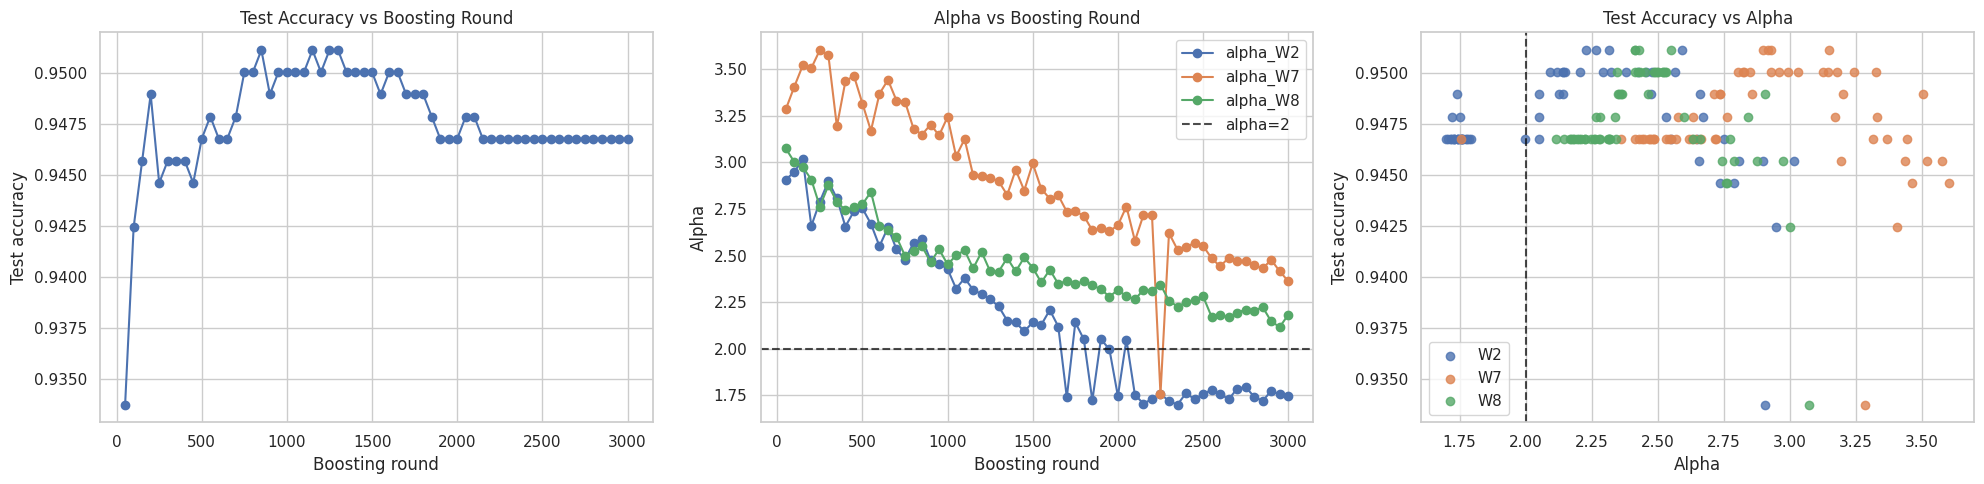

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))

alpha_cols = [c for c in results_df.columns if c.startswith('alpha_')]

# Plot 1: Accuracy vs boosting round
axes[0].plot(results_df['boosting_round'], results_df['test_accuracy'], marker='o')
axes[0].set_title('Test Accuracy vs Boosting Round')
axes[0].set_xlabel('Boosting round')
axes[0].set_ylabel('Test accuracy')

# Plot 2: Alpha vs boosting round (all requested W matrices)
for col in alpha_cols:
    axes[1].plot(results_df['boosting_round'], results_df[col], marker='o', label=col)
axes[1].axhline(2.0, linestyle='--', color='black', alpha=0.7, label='alpha=2')
axes[1].set_title('Alpha vs Boosting Round')
axes[1].set_xlabel('Boosting round')
axes[1].set_ylabel('Alpha')
axes[1].legend(ncol=2, fontsize=9)

# Plot 3: Accuracy vs alpha
for col in alpha_cols:
    axes[2].scatter(results_df[col], results_df['test_accuracy'], label=col, alpha=0.75)
axes[2].axvline(2.0, linestyle='--', color='black', alpha=0.7)
axes[2].set_title('Accuracy vs Alpha')
axes[2].set_xlabel('Alpha')
axes[2].set_ylabel('Test accuracy')
axes[2].legend(ncol=2, fontsize=9)

plt.tight_layout()
plt.show()


## 9) HTSR hypothesis check and final summary table

In [27]:
summary_cols = ['boosting_round', 'test_accuracy'] + [c for c in results_df.columns if c.startswith('alpha_')]

best_idx = results_df['test_accuracy'].idxmax()
best_row = results_df.loc[best_idx, summary_cols]
print('Best-accuracy row:')
display(best_row.to_frame().T)

near_best = results_df.sort_values('test_accuracy', ascending=False).head(10).copy()
near_best = near_best[summary_cols].sort_values('boosting_round')
print('Alpha values near peak accuracy (top-10 rounds):')
display(near_best)

print('\nStart -> end alpha trend:')
for col in [c for c in summary_cols if c.startswith('alpha_')]:
    print(f'{col}: {results_df[col].iloc[0]:.3f} -> {results_df[col].iloc[-1]:.3f}')

print('\nAccuracy/alpha correlations:')
for col in [c for c in summary_cols if c.startswith('alpha_')]:
    corr = results_df['test_accuracy'].corr(results_df[col])
    print(f'corr(test_accuracy, {col}) = {corr:.4f}')


Best-accuracy row:


,boosting_round,test_accuracy,alpha_W2,alpha_W7,alpha_W8
16,850.0,0.95114,2.590515,3.14902,2.550222


Alpha values near peak accuracy (top-10 rounds):


,boosting_round,test_accuracy,alpha_W2,alpha_W7,alpha_W8
14,750,0.950054,2.478364,3.326406,2.498635
15,800,0.950054,2.567250,3.181107,2.521911
16,850,0.951140,2.590515,3.149020,2.550222
18,950,0.950054,2.457099,3.145018,2.533306
19,1000,0.950054,2.427242,3.243900,2.452783
20,1050,0.950054,2.322335,3.032552,2.500495
22,1150,0.951140,2.316546,2.931043,2.430754
24,1250,0.951140,2.264981,2.917711,2.415086
25,1300,0.951140,2.226935,2.898790,2.414232
26,1350,0.950054,2.150557,2.825352,2.486558



Start -> end alpha trend:
alpha_W2: 2.908 -> 1.745
alpha_W7: 3.285 -> 2.362
alpha_W8: 3.075 -> 2.182

Accuracy/alpha correlations:
corr(test_accuracy, alpha_W2) = -0.1699
corr(test_accuracy, alpha_W7) = -0.0785
corr(test_accuracy, alpha_W8) = -0.3369


### Interpretation guide
- Built for Adult Income with stronger regularization and long-run checkpointing.
- Tracks **W1, W2, W7, W8, W9, W10** at each checkpointed stage.
- HTSR-style behavior is suggested if test accuracy stabilizes while alpha values remain in a robust heavy-tailed range (often around/above 2).
